In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load file csv
df = pd.read_csv(r"../data/pizza_sales.csv")

# Order Date exsist
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

### A) KPI's section

In [9]:
# 1. Total Revenue 
total_revenue = df['total_price'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 817860.0499999999


In [10]:
# 2. Average Order Value
avg_order_value = df.groupby('order_id')['total_price'].sum().mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 38.30726229508197


In [11]:
# 3. Total Pizzas Sold
total_pizza_sold = df['quantity'].sum()
print("Total Pizzas Sold:", total_pizza_sold)

Total Pizzas Sold: 49574


In [12]:
# 4. Total Orders
total_orders = df['order_id'].nunique()
print("Total Orders:", total_orders)

Total Orders: 21350


In [13]:
# 5. Average Pizzas Per Order
avg_pizza_per_order = df['quantity'].sum() / df['order_id'].nunique()
print("Avg Pizzas per Order:", avg_pizza_per_order)

Avg Pizzas per Order: 2.321967213114754


# KPI's and Charts

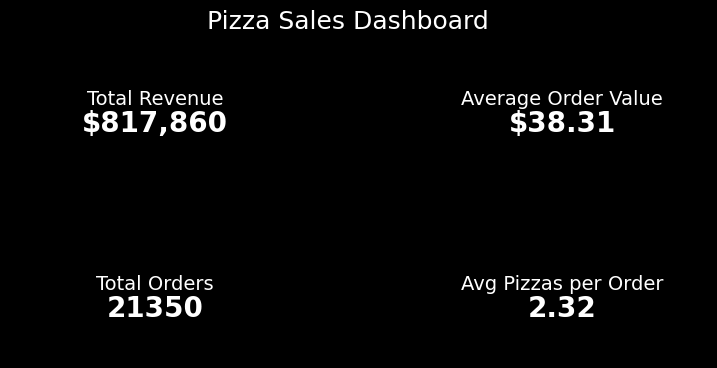

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(9,4))

# Set overall dashboard background to black
fig.patch.set_facecolor('black')

kpis = [
    ("Total Revenue", f"${total_revenue:,.0f}"),
    ("Average Order Value", f"${avg_order_value:.2f}"),
    ("Total Orders", f"{total_orders}"),
    ("Avg Pizzas per Order", f"{avg_pizza_per_order:.2f}")
]

for ax, (title, value) in zip(axes.flatten(), kpis):
    ax.set_facecolor('black')
    
    # Title (top)
    ax.text(0.5, 0.6, title, ha='center', va='center',
            fontsize=14, color='white')
    
    # Value (below title, larger)
    ax.text(0.5, 0.4, value, ha='center', va='center',
            fontsize=20, color='white', fontweight='bold')
    
    ax.axis('off')

# Dashboard title
plt.suptitle("Pizza Sales Dashboard", fontsize=18, color='white')

# Adjust spacing between KPI cards
plt.subplots_adjust(wspace=0.4, hspace=0.5)

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/pizza_sales_dashboard.png", dpi=300, facecolor='black')

plt.show()

### B) Daily Trend (Orders)


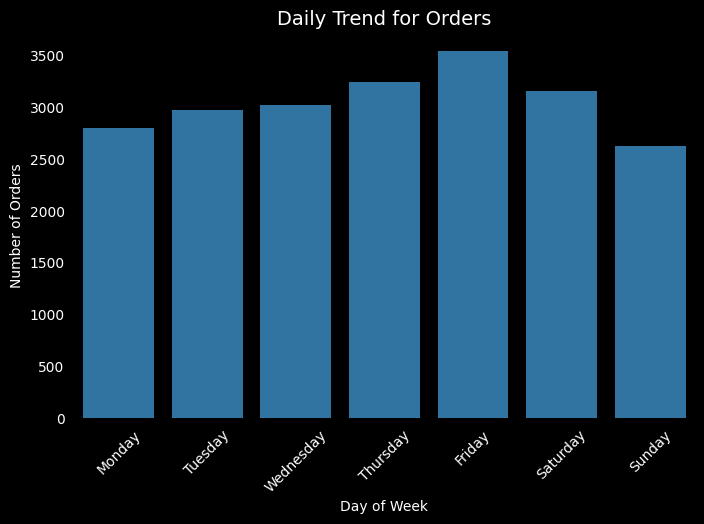

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

daily_trend = df.groupby(df['order_date'].dt.day_name())['order_id'].nunique()

# Sort days correctly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_trend = daily_trend.reindex(day_order)

# Create figure
plt.figure(figsize=(8,5))
ax = plt.gca()

# Set background to black
plt.gcf().patch.set_facecolor('black')
ax.set_facecolor('black')

# Plot
sns.barplot(x=daily_trend.index, y=daily_trend.values)

# Titles and labels (white)
plt.title("Daily Trend for Orders", color='white', fontsize=14)
plt.xlabel("Day of Week", color='white')
plt.ylabel("Number of Orders", color='white')

# Axis ticks color
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Remove spines (clean look)
for spine in ax.spines.values():
    spine.set_visible(False)

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Daily_Trend_dashboard.png", dpi=300, facecolor='black')

plt.show()

### C) Monthly Trend


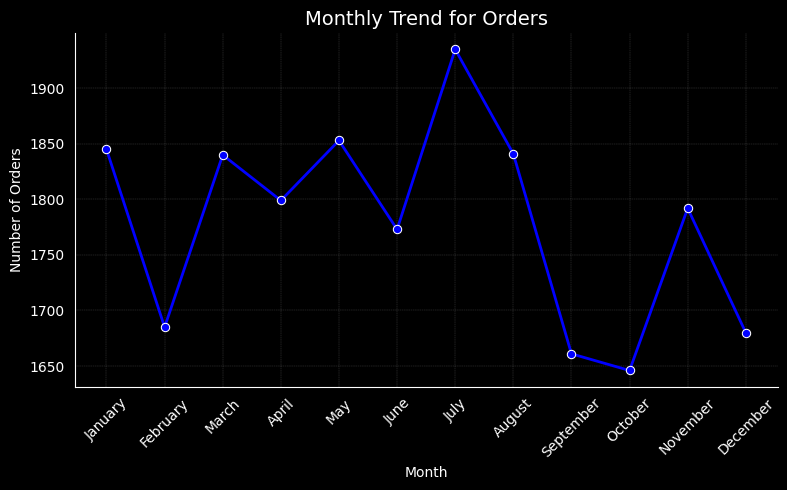

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

monthly_trend = df.groupby(df['order_date'].dt.month_name())['order_id'].nunique()

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_trend = monthly_trend.reindex(month_order)

fig, ax = plt.subplots(figsize=(8,5))

# Background BLACK for saving image
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Line (blue / blau)
sns.lineplot(
    x=monthly_trend.index,
    y=monthly_trend.values,
    marker="o",
    linewidth=2,
    color="blue"
)

# Titles (white)
plt.title("Monthly Trend for Orders", color='white', fontsize=14)
plt.xlabel("Month", color='white')
plt.ylabel("Number of Orders", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Monthly_Trend_dashboard.png", dpi=300, facecolor='black')

plt.show()

### D) % Sales by Category

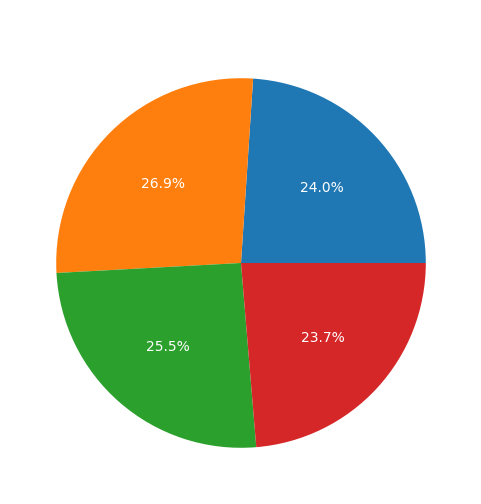

In [22]:
import matplotlib.pyplot as plt

category_sales = df.groupby('pizza_category')['total_price'].sum()
category_pct = (category_sales / category_sales.sum()) * 100

# Create figure
fig, ax = plt.subplots(figsize=(6,6))

# Remove background (transparent)
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Pie chart
wedges, texts, autotexts = ax.pie(
    category_pct,
    labels=category_pct.index,
    autopct='%1.1f%%',
    textprops={'color': 'white'}  
)

# Title
plt.title("Sales % by Category" , color='white')

plt.ylabel("")

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/%Sales_by_Category_dashboard.png", dpi=300, facecolor='black')

plt.show()

### E) % Sales by Size

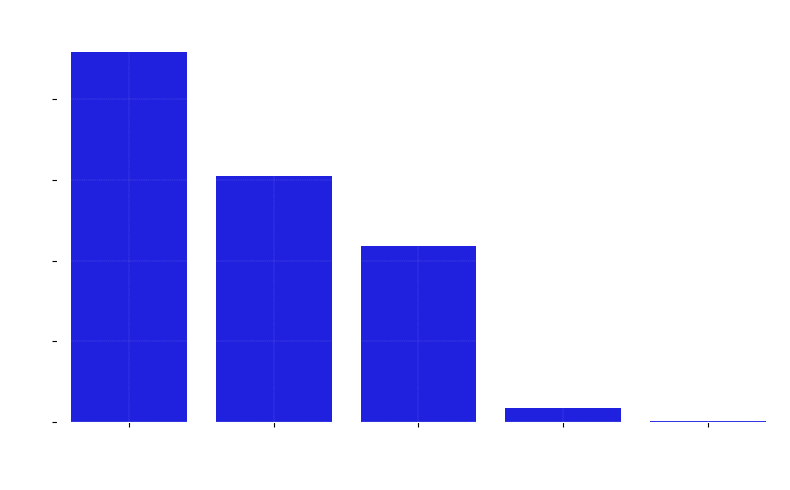

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

size_sales = df.groupby('pizza_size')['total_price'].sum()
size_pct = (size_sales / size_sales.sum()) * 100

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(x=size_pct.index, y=size_pct.values, color="blue")

# Title and labels (white)
plt.title("% Sales by Pizza Size", color='white', fontsize=14)
plt.xlabel("Pizza Size", color='white')
plt.ylabel("Percentage of Revenue (%)", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()


# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/%Sales_by_Size_dashboard.png", dpi=300, facecolor='black')


plt.show()

### F) Total Pizzas Sold by Category (February)

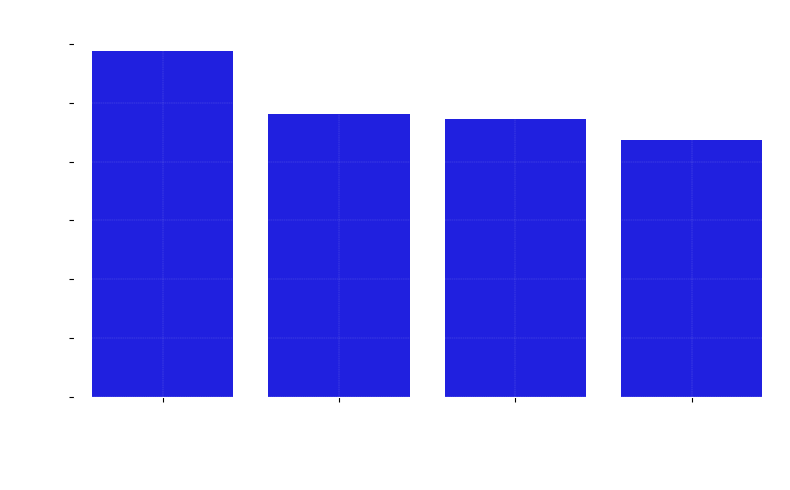

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

feb_df = df[df['order_date'].dt.month == 2]

category_qty = feb_df.groupby('pizza_category')['quantity'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=category_qty.index,
    y=category_qty.values,
    color="blue"
)

# Title and labels (white)
plt.title("Pizzas Sold by Category (Feb)", color='white', fontsize=14)
plt.xlabel("Pizza Category", color='white')
plt.ylabel("Number of Pizzas Sold", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()


# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Pizzas_Sold_by_Category(Feb)_dashboard.png", dpi=300, facecolor='black')

plt.show()

### G) Top 5 Pizzas by Revenue

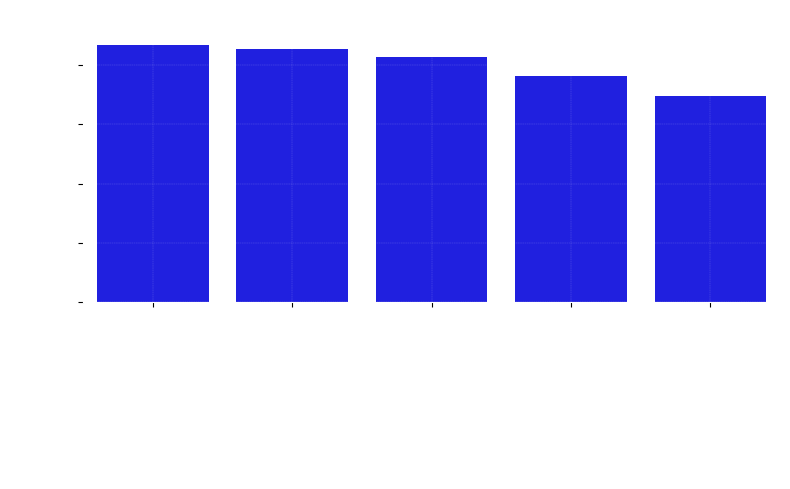

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

top5_revenue = df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=top5_revenue.index,
    y=top5_revenue.values,
    color="blue"
)

# Title and labels (white)
plt.title("Top 5 Pizzas by Revenue", color='white', fontsize=14)
plt.xlabel("Pizza Name", color='white')
plt.ylabel("Revenue ($)", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Top_5_Pizzas_by_Revenue_dashboard.png", dpi=300, facecolor='black')

plt.show()

### H) Bottom 5 Pizzas by Revenue

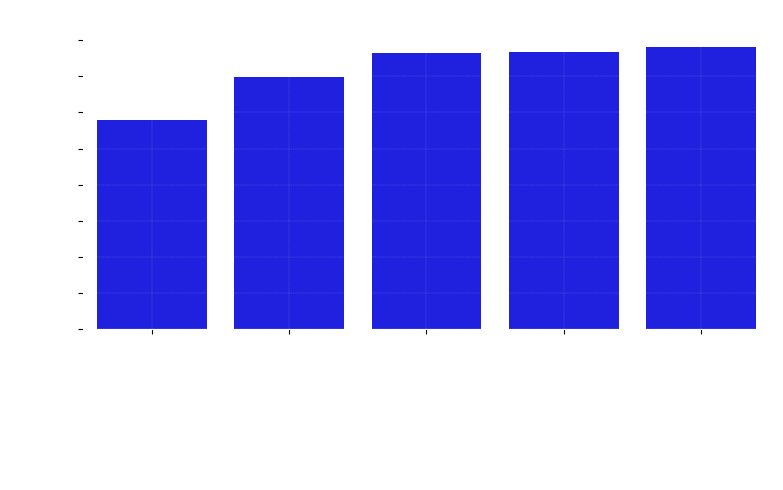

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

bottom5_revenue = df.groupby('pizza_name')['total_price'].sum().sort_values().head(5)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=bottom5_revenue.index,
    y=bottom5_revenue.values,
    color="blue"
)

# Title and labels (white)
plt.title("Bottom 5 Pizzas by Revenue", color='white', fontsize=14)
plt.xlabel("Pizza Name", color='white')
plt.ylabel("Revenue ($)", color='white')

# Ticks (white)
plt.xticks(rotation=35, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Bottom_5_Pizzas_by_Revenue_dashboard.png", dpi=300, facecolor='black')

plt.show()

### I) Top 5 by Quantity

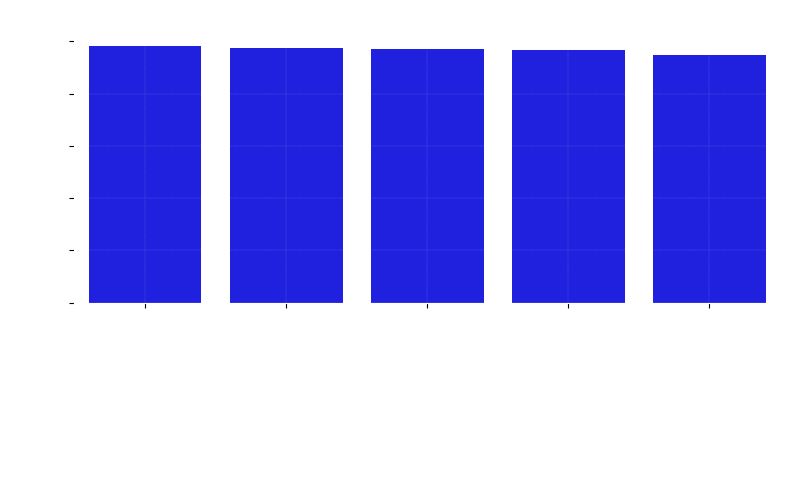

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

top5_qty = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=top5_qty.index,
    y=top5_qty.values,
    color="blue"
)

# Title and labels (white)
plt.title("Top 5 Pizzas by Quantity", color='white', fontsize=14)
plt.xlabel("Pizza Name", color='white')
plt.ylabel("Quantity Sold", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()


# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Top_5_Pizzas_by_Quantity_dashboard.png", dpi=300, facecolor='black')

plt.show()

### J) Bottom 5 by Quantity

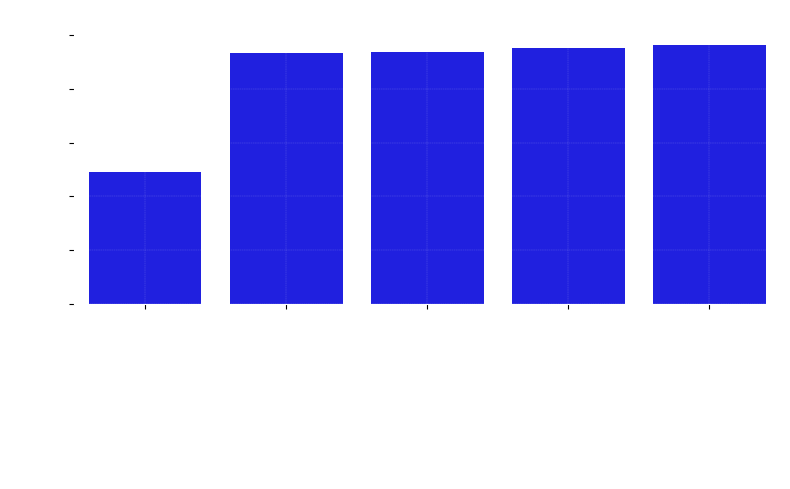

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

bottom5_qty = df.groupby('pizza_name')['quantity'].sum().sort_values().head(5)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=bottom5_qty.index,
    y=bottom5_qty.values,
    color="blue"
)

# Title and labels (white)
plt.title("Bottom 5 Pizzas by Quantity", color='white', fontsize=14)
plt.xlabel("Pizza Name", color='white')
plt.ylabel("Quantity Sold", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (soft white)
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Bottom_5_Pizzas_by_Quantity_dashboard.png", dpi=300, facecolor='black')

plt.show()

### K) Top 5 by Orders

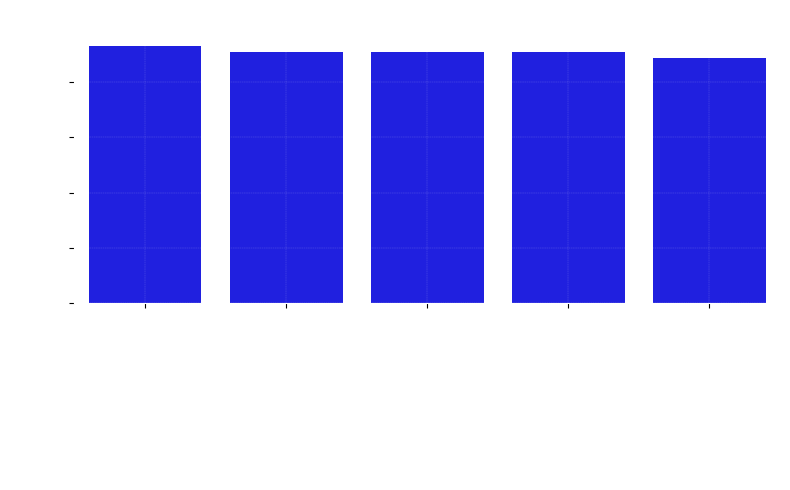

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

top5_orders = df.groupby('pizza_name')['order_id'].nunique().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=top5_orders.index,
    y=top5_orders.values,
    color="blue"
)

# Add values on top of bars
for i, v in enumerate(top5_orders.values):
    ax.text(i, v + 0.5, str(v), color='white', ha='center', fontsize=10)

# Title and labels (white)
plt.title("Top 5 Pizzas by Orders", color='white', fontsize=14)
plt.xlabel("Pizza Name", color='white')
plt.ylabel("Number of Unique Orders", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Top_5_Pizzas_by_Orders_dashboard.png", dpi=300, facecolor='black')

plt.show()

### L) Bottom 5 by Orders

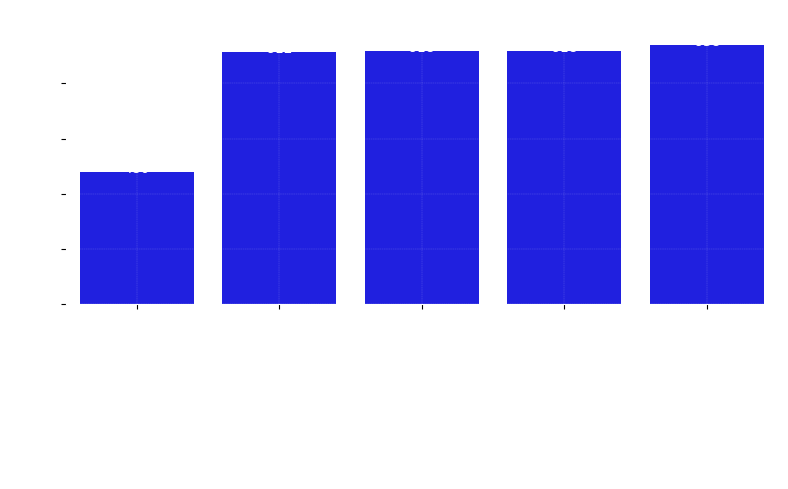

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

bottom5_orders = df.groupby('pizza_name')['order_id'].nunique().sort_values().head(5)

fig, ax = plt.subplots(figsize=(8,5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# Bar plot
sns.barplot(
    x=bottom5_orders.index,
    y=bottom5_orders.values,
    color="blue"
)

# Add values on bars
for i, v in enumerate(bottom5_orders.values):
    ax.text(i, v + 0.5, str(v), color='white', ha='center', fontsize=10)

# Title and labels (white)
plt.title("Bottom 5 Pizzas by Orders", color='white', fontsize=14)
plt.xlabel("Pizza Name", color='white')
plt.ylabel("Number of Unique Orders", color='white')

# Ticks (white)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# Axis lines (white)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.tight_layout()

# SAVE IMAGE (IMPORTANT)
plt.savefig("../screenshots/Bottom_5_Pizzas_by_Orders_dashboard.png", dpi=300, facecolor='black')

plt.show()